In [ ]:
!pip install google-cloud-storage

In [ ]:
from google.colab import auth
auth.authenticate_user()

In [ ]:
from google.cloud import storage

# Initialize the client
client = storage.Client()
bucket = client.get_bucket('news_articles-bucket')

In [ ]:
import json
import pandas as pd
# Download files (assuming they are JSON)
blobs = bucket.list_blobs()
data_list = []

for blob in blobs:
    # Download blob content
    content = blob.download_as_string()
    data = json.loads(content)  # Load JSON data if in JSON format
    data_list.append(data)

# Convert to DataFrame if each file is a JSON object representing one row
df = pd.DataFrame(data_list)

In [ ]:
df

,ticker,title,summary,content,published_utc
0,AAPL,1 Great Reason to Buy the Vanguard Dividend Ap...,The article highlights the Vanguard Dividend A...,"Founded in 1993, The Motley Fool is a financia...",2024-11-02T12:10:00Z
1,AAPL,Is Warren Buffett's $2.9 Billion Bet and Sales...,Warren Buffett has been selling shares of his ...,"Founded in 1993, The Motley Fool is a financia...",2024-11-02T07:30:00Z
2,AAPL,Prediction: Election Day Will Represent an Omi...,The article discusses the potential impact of ...,"Founded in 1993, The Motley Fool is a financia...",2024-11-02T08:06:00Z
3,AAPL,1 Great Reason to Buy the Vanguard Dividend Ap...,The article highlights the Vanguard Dividend A...,"Founded in 1993, The Motley Fool is a financia...",2024-11-02T12:10:00Z
4,AAPL,You'll Never Believe What Taiwan Semiconductor...,Taiwan Semiconductor Manufacturing (TSMC) CEO ...,"Founded in 1993, The Motley Fool is a financia...",2024-11-03T11:53:00Z
5,AMZN,Billionaire Israel Englander Just Tripled His ...,"Billionaire investors Warren Buffett, Cathie W...","Founded in 1993, The Motley Fool is a financia...",2024-11-02T09:45:00Z
6,AMZN,"NuScale Power: Buy, Sell, or Hold?",NuScale Power is a nuclear power company devel...,"Founded in 1993, The Motley Fool is a financia...",2024-11-02T07:30:00Z
7,AMZN,Amazon Just Gave 4 Great Reasons to Buy Its St...,"Amazon reported strong Q3 results, with impres...","Founded in 1993, The Motley Fool is a financia...",2024-11-02T08:52:00Z
8,AMZN,Billionaire Israel Englander Just Tripled His ...,"Billionaire investors Warren Buffett, Cathie W...","Founded in 1993, The Motley Fool is a financia...",2024-11-02T09:45:00Z
9,AMZN,Billionaire Israel Englander Just Tripled His ...,"Billionaire investors Warren Buffett, Cathie W...","Founded in 1993, The Motley Fool is a financia...",2024-11-02T09:45:00Z


In [ ]:
# Define a function to clean text directly in the original columns
def clean_text(text):
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    # Remove non-alphanumeric characters (keeping basic punctuation)
    text = re.sub(r'[^a-zA-Z0-9.,?!\s]', '', text)
    return text

In [ ]:
df.columns

Index(['ticker', 'title', 'summary', 'content', 'published_utc'], dtype='object')

In [ ]:
# Convert date columns to YYYY-MM-DD format
df['published_utc'] = pd.to_datetime(df['published_utc'], errors='coerce').dt.strftime('%Y-%m-%d')



In [ ]:
import re
df['title'] = df['title'].apply(clean_text)
df['summary'] = df['summary'].apply(clean_text)
df['content'] = df['content'].apply(clean_text)

In [ ]:
df.fillna('', inplace=True)

In [ ]:
df

,ticker,title,summary,content,published_utc
0,AAPL,1 Great Reason to Buy the Vanguard Dividend Ap...,The article highlights the Vanguard Dividend A...,"Founded in 1993, The Motley Fool is a financia...",2024-11-02
1,AAPL,Is Warren Buffetts 2.9 Billion Bet and Sales o...,Warren Buffett has been selling shares of his ...,"Founded in 1993, The Motley Fool is a financia...",2024-11-02
2,AAPL,Prediction Election Day Will Represent an Omin...,The article discusses the potential impact of ...,"Founded in 1993, The Motley Fool is a financia...",2024-11-02
3,AAPL,1 Great Reason to Buy the Vanguard Dividend Ap...,The article highlights the Vanguard Dividend A...,"Founded in 1993, The Motley Fool is a financia...",2024-11-02
4,AAPL,Youll Never Believe What Taiwan Semiconductors...,Taiwan Semiconductor Manufacturing TSMC CEO re...,"Founded in 1993, The Motley Fool is a financia...",2024-11-03
5,AMZN,Billionaire Israel Englander Just Tripled His ...,"Billionaire investors Warren Buffett, Cathie W...","Founded in 1993, The Motley Fool is a financia...",2024-11-02
6,AMZN,"NuScale Power Buy, Sell, or Hold?",NuScale Power is a nuclear power company devel...,"Founded in 1993, The Motley Fool is a financia...",2024-11-02
7,AMZN,Amazon Just Gave 4 Great Reasons to Buy Its St...,"Amazon reported strong Q3 results, with impres...","Founded in 1993, The Motley Fool is a financia...",2024-11-02
8,AMZN,Billionaire Israel Englander Just Tripled His ...,"Billionaire investors Warren Buffett, Cathie W...","Founded in 1993, The Motley Fool is a financia...",2024-11-02
9,AMZN,Billionaire Israel Englander Just Tripled His ...,"Billionaire investors Warren Buffett, Cathie W...","Founded in 1993, The Motley Fool is a financia...",2024-11-02


In [ ]:
# Assuming you have a datetime column
df['published_utc'] = pd.to_datetime(df['published_utc'])
df.set_index('published_utc', inplace=True)

# Aggregating by month
monthly_agg = df.resample('ME').agg({
    'summary': 'count'  # Count of articles per month
})


In [ ]:
print(monthly_agg)

               summary
published_utc         
2024-10-31          15
2024-11-30          43


In [ ]:
!pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.1 MB/s eta 0:00:00


In [ ]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
analyzer = SentimentIntensityAnalyzer()

def sentiment_analysis(text):
    score = analyzer.polarity_scores(text)
    return score['compound']  # Returning compound score

df['sentiment'] = df['summary'].apply(sentiment_analysis)


In [ ]:
df

,ticker,title,summary,content,sentiment
published_utc,,,,,
2024-11-02,AAPL,1 Great Reason to Buy the Vanguard Dividend Ap...,The article highlights the Vanguard Dividend A...,"Founded in 1993, The Motley Fool is a financia...",0.5719
2024-11-02,AAPL,Is Warren Buffetts 2.9 Billion Bet and Sales o...,Warren Buffett has been selling shares of his ...,"Founded in 1993, The Motley Fool is a financia...",0.7184
2024-11-02,AAPL,Prediction Election Day Will Represent an Omin...,The article discusses the potential impact of ...,"Founded in 1993, The Motley Fool is a financia...",0.4939
2024-11-02,AAPL,1 Great Reason to Buy the Vanguard Dividend Ap...,The article highlights the Vanguard Dividend A...,"Founded in 1993, The Motley Fool is a financia...",0.5719
2024-11-03,AAPL,Youll Never Believe What Taiwan Semiconductors...,Taiwan Semiconductor Manufacturing TSMC CEO re...,"Founded in 1993, The Motley Fool is a financia...",0.4215
2024-11-02,AMZN,Billionaire Israel Englander Just Tripled His ...,"Billionaire investors Warren Buffett, Cathie W...","Founded in 1993, The Motley Fool is a financia...",0.8316
2024-11-02,AMZN,"NuScale Power Buy, Sell, or Hold?",NuScale Power is a nuclear power company devel...,"Founded in 1993, The Motley Fool is a financia...",0.4588
2024-11-02,AMZN,Amazon Just Gave 4 Great Reasons to Buy Its St...,"Amazon reported strong Q3 results, with impres...","Founded in 1993, The Motley Fool is a financia...",0.9801
2024-11-02,AMZN,Billionaire Israel Englander Just Tripled His ...,"Billionaire investors Warren Buffett, Cathie W...","Founded in 1993, The Motley Fool is a financia...",0.8316


In [ ]:
daily_sentiment = df.groupby('published_utc').agg({'sentiment': 'mean'}).reset_index()

# Display the resulting DataFrame with daily average sentiment
print(daily_sentiment)

  published_utc  sentiment
0    2024-10-29   0.773667
1    2024-10-30   0.549150
2    2024-10-31   0.541462
3    2024-11-01   0.778300
4    2024-11-02   0.637677
5    2024-11-03   0.749058


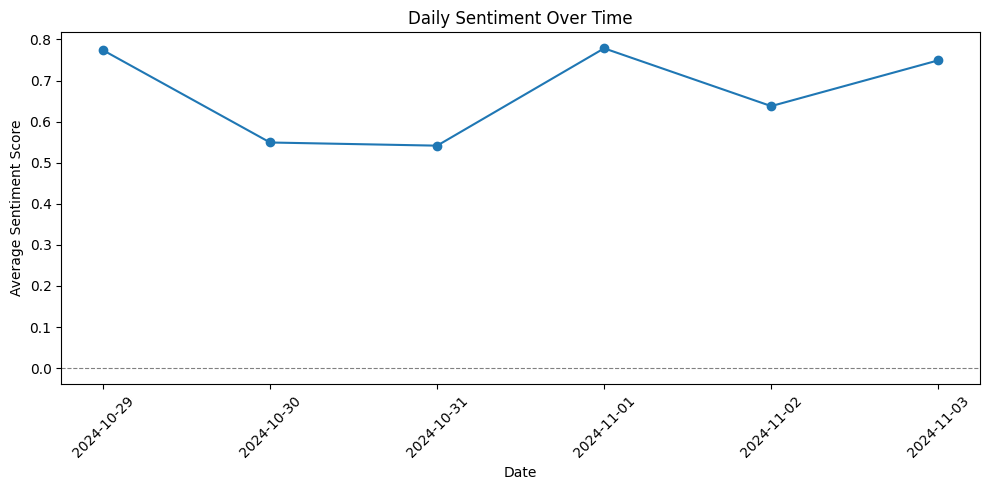

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(daily_sentiment['published_utc'], daily_sentiment['sentiment'], marker='o')
plt.title('Daily Sentiment Over Time')
plt.xlabel('Date')
plt.ylabel('Average Sentiment Score')
plt.xticks(rotation=45)
plt.axhline(0, color='gray', linewidth=0.8, linestyle='--')  # Add a line at y=0 for reference
plt.tight_layout()  # Adjust layout to prevent clipping of labels
plt.show()


In [ ]:
!pip install pyarrow

In [ ]:
# Save the DataFrame to Parquet format
df.to_parquet('processed_data.parquet', engine='pyarrow', index=False)

In [ ]:
df


,ticker,title,summary,content,sentiment
published_utc,,,,,
2024-11-02,AAPL,1 Great Reason to Buy the Vanguard Dividend Ap...,The article highlights the Vanguard Dividend A...,"Founded in 1993, The Motley Fool is a financia...",0.5719
2024-11-02,AAPL,Is Warren Buffetts 2.9 Billion Bet and Sales o...,Warren Buffett has been selling shares of his ...,"Founded in 1993, The Motley Fool is a financia...",0.7184
2024-11-02,AAPL,Prediction Election Day Will Represent an Omin...,The article discusses the potential impact of ...,"Founded in 1993, The Motley Fool is a financia...",0.4939
2024-11-02,AAPL,1 Great Reason to Buy the Vanguard Dividend Ap...,The article highlights the Vanguard Dividend A...,"Founded in 1993, The Motley Fool is a financia...",0.5719
2024-11-03,AAPL,Youll Never Believe What Taiwan Semiconductors...,Taiwan Semiconductor Manufacturing TSMC CEO re...,"Founded in 1993, The Motley Fool is a financia...",0.4215
2024-11-02,AMZN,Billionaire Israel Englander Just Tripled His ...,"Billionaire investors Warren Buffett, Cathie W...","Founded in 1993, The Motley Fool is a financia...",0.8316
2024-11-02,AMZN,"NuScale Power Buy, Sell, or Hold?",NuScale Power is a nuclear power company devel...,"Founded in 1993, The Motley Fool is a financia...",0.4588
2024-11-02,AMZN,Amazon Just Gave 4 Great Reasons to Buy Its St...,"Amazon reported strong Q3 results, with impres...","Founded in 1993, The Motley Fool is a financia...",0.9801
2024-11-02,AMZN,Billionaire Israel Englander Just Tripled His ...,"Billionaire investors Warren Buffett, Cathie W...","Founded in 1993, The Motley Fool is a financia...",0.8316


In [ ]:
# Define your bucket name and file path
bucket_name = 'news_article-bucket_preprocessed'
destination_blob_name = '/content/processed_data.parquet'

# Retrieve the bucket and upload the file
bucket = client.get_bucket(bucket_name)
blob = bucket.blob(destination_blob_name)

# Upload the Parquet file
blob.upload_from_filename('processed_data.parquet')

print("File uploaded to GCS bucket successfully.")


File uploaded to GCS bucket successfully.


In [ ]:
import os
# Create output directory for storing files
output_dir = 'news_articles_parquet'
os.makedirs(output_dir, exist_ok=True)

# Iterate over each date and ticker group
for (date, ticker), group in df.groupby([df.index.date, 'ticker']):
    # Define the file name based on date and ticker
    filename = f"{ticker}_{date}.parquet"
    file_path = os.path.join(output_dir, filename)

    # Save each group as a separate Parquet file
    group.to_parquet(file_path, index=True)
    print(f"Saved {file_path}")

Saved news_articles_parquet/MA_2024-10-29.parquet
Saved news_articles_parquet/V_2024-10-29.parquet
Saved news_articles_parquet/PG_2024-10-30.parquet
Saved news_articles_parquet/WMT_2024-10-30.parquet
Saved news_articles_parquet/JNJ_2024-10-31.parquet
Saved news_articles_parquet/JPM_2024-10-31.parquet
Saved news_articles_parquet/TSLA_2024-10-31.parquet
Saved news_articles_parquet/UNH_2024-10-31.parquet
Saved news_articles_parquet/META_2024-11-01.parquet
Saved news_articles_parquet/AAPL_2024-11-02.parquet
Saved news_articles_parquet/AMZN_2024-11-02.parquet
Saved news_articles_parquet/BRK.B_2024-11-02.parquet
Saved news_articles_parquet/GOOGL_2024-11-02.parquet
Saved news_articles_parquet/JPM_2024-11-02.parquet
Saved news_articles_parquet/META_2024-11-02.parquet
Saved news_articles_parquet/MSFT_2024-11-02.parquet
Saved news_articles_parquet/NVDA_2024-11-02.parquet
Saved news_articles_parquet/V_2024-11-02.parquet
Saved news_articles_parquet/AAPL_2024-11-03.parquet
Saved news_articles_parqu

In [ ]:
df_aapl_nov2 = pd.read_parquet(f'{output_dir}/AAPL_2024-11-02.parquet', engine='pyarrow')
print(df_aapl_nov2)

              ticker                                              title  \
published_utc                                                             
2024-11-02      AAPL  1 Great Reason to Buy the Vanguard Dividend Ap...   
2024-11-02      AAPL  Is Warren Buffetts 2.9 Billion Bet and Sales o...   
2024-11-02      AAPL  Prediction Election Day Will Represent an Omin...   
2024-11-02      AAPL  1 Great Reason to Buy the Vanguard Dividend Ap...   

                                                         summary  \
published_utc                                                      
2024-11-02     The article highlights the Vanguard Dividend A...   
2024-11-02     Warren Buffett has been selling shares of his ...   
2024-11-02     The article discusses the potential impact of ...   
2024-11-02     The article highlights the Vanguard Dividend A...   

                                                         content  sentiment  
published_utc                                                 

In [ ]:
# Define your GCS bucket name
bucket_name = 'news_article-bucket_preprocessed'

# Initialize the GCS client
client = storage.Client()

# Get the bucket
bucket = client.bucket(bucket_name)

# Define the directory containing your Parquet files
output_dir = 'news_articles_parquet'

# Upload each Parquet file to GCS
for filename in os.listdir(output_dir):
    if filename.endswith('.parquet'):
        # Full path to the file
        file_path = os.path.join(output_dir, filename)

        # Create a blob in the bucket (blob name will be the filename here)
        blob = bucket.blob(filename)

        # Upload the file to GCS
        blob.upload_from_filename(file_path)
        print(f"Uploaded {filename} to GCS bucket {bucket_name} as {filename}")

Uploaded TSLA_2024-10-31.parquet to GCS bucket news_article-bucket_preprocessed as TSLA_2024-10-31.parquet
Uploaded META_2024-11-03.parquet to GCS bucket news_article-bucket_preprocessed as META_2024-11-03.parquet
Uploaded META_2024-11-02.parquet to GCS bucket news_article-bucket_preprocessed as META_2024-11-02.parquet
Uploaded PG_2024-11-03.parquet to GCS bucket news_article-bucket_preprocessed as PG_2024-11-03.parquet
Uploaded AMZN_2024-11-02.parquet to GCS bucket news_article-bucket_preprocessed as AMZN_2024-11-02.parquet
Uploaded AAPL_2024-11-03.parquet to GCS bucket news_article-bucket_preprocessed as AAPL_2024-11-03.parquet
Uploaded TSLA_2024-11-03.parquet to GCS bucket news_article-bucket_preprocessed as TSLA_2024-11-03.parquet
Uploaded AAPL_2024-11-02.parquet to GCS bucket news_article-bucket_preprocessed as AAPL_2024-11-02.parquet
Uploaded V_2024-11-02.parquet to GCS bucket news_article-bucket_preprocessed as V_2024-11-02.parquet
Uploaded JNJ_2024-10-31.parquet to GCS bucket n

In [ ]:
import os
base_output_dir = 'news_articles_parquet'
os.makedirs(base_output_dir, exist_ok=True)

# Iterate over each company and date
for (company, date), group in df.groupby(['ticker', df.index.date]):
    # Define the folder structure
    company_folder = os.path.join(base_output_dir, company)
    os.makedirs(company_folder, exist_ok=True)

    # Define the file name based on date
    filename = f"{date}.parquet"
    file_path = os.path.join(company_folder, filename)

    # Save each group as a separate Parquet file
    group.to_parquet(file_path, index=True)
    print(f"Saved {file_path}")

Saved company_news_parquet/AAPL/2024-11-02.parquet
Saved company_news_parquet/AAPL/2024-11-03.parquet
Saved company_news_parquet/AMZN/2024-11-02.parquet
Saved company_news_parquet/AMZN/2024-11-03.parquet
Saved company_news_parquet/BRK.B/2024-11-02.parquet
Saved company_news_parquet/BRK.B/2024-11-03.parquet
Saved company_news_parquet/GOOGL/2024-11-02.parquet
Saved company_news_parquet/GOOGL/2024-11-03.parquet
Saved company_news_parquet/JNJ/2024-10-31.parquet
Saved company_news_parquet/JPM/2024-10-31.parquet
Saved company_news_parquet/JPM/2024-11-02.parquet
Saved company_news_parquet/MA/2024-10-29.parquet
Saved company_news_parquet/META/2024-11-01.parquet
Saved company_news_parquet/META/2024-11-02.parquet
Saved company_news_parquet/META/2024-11-03.parquet
Saved company_news_parquet/MSFT/2024-11-02.parquet
Saved company_news_parquet/MSFT/2024-11-03.parquet
Saved company_news_parquet/NVDA/2024-11-02.parquet
Saved company_news_parquet/NVDA/2024-11-03.parquet
Saved company_news_parquet/PG/20

In [ ]:
def upload_to_gcs(bucket_name, local_folder):
    # Initialize GCS client
    client = storage.Client()
    bucket = client.get_bucket(bucket_name)

    # Walk through local folder and upload files to GCS
    for root, _, files in os.walk(local_folder):
        for file in files:
            if file.endswith('.parquet'):
                local_path = os.path.join(root, file)

                # Define GCS path to match folder structure
                relative_path = os.path.relpath(local_path, local_folder)
                blob = bucket.blob(f"{relative_path}")

                # Upload the file to GCS
                blob.upload_from_filename(local_path)
                print(f"Uploaded {relative_path} to {bucket_name}")

# Specify the name of your GCS bucket and the local folder containing Parquet files
bucket_name = 'news_article-bucket_preprocessed'
upload_to_gcs(bucket_name, base_output_dir)


Uploaded BRK.B/2024-11-03.parquet to news_article-bucket_preprocessed
Uploaded BRK.B/2024-11-02.parquet to news_article-bucket_preprocessed
Uploaded UNH/2024-10-31.parquet to news_article-bucket_preprocessed
Uploaded JPM/2024-11-02.parquet to news_article-bucket_preprocessed
Uploaded JPM/2024-10-31.parquet to news_article-bucket_preprocessed
Uploaded MSFT/2024-11-03.parquet to news_article-bucket_preprocessed
Uploaded MSFT/2024-11-02.parquet to news_article-bucket_preprocessed
Uploaded JNJ/2024-10-31.parquet to news_article-bucket_preprocessed
Uploaded WMT/2024-11-03.parquet to news_article-bucket_preprocessed
Uploaded WMT/2024-10-30.parquet to news_article-bucket_preprocessed
Uploaded NVDA/2024-11-03.parquet to news_article-bucket_preprocessed
Uploaded NVDA/2024-11-02.parquet to news_article-bucket_preprocessed
Uploaded PG/2024-11-03.parquet to news_article-bucket_preprocessed
Uploaded PG/2024-10-30.parquet to news_article-bucket_preprocessed
Uploaded GOOGL/2024-11-03.parquet to news_